# Bloch Equations: Free Precession After a 90° RF Pulse

We solve the **Bloch equations** for the magnetization $\mathbf{M}=(M_x, M_y, M_z)$ in a
**homogeneous static field** $\mathbf{B}_0 = B_0\,\hat{z}$, following a 90° excitation pulse.

The Bloch equations are
$$\frac{d\mathbf{M}}{dt} = \gamma\,\mathbf{M}\times\mathbf{B}
  - \frac{M_x\hat{x}+M_y\hat{y}}{T_2} - \frac{(M_z-M_0)\hat{z}}{T_1}.$$

With $\mathbf{B}=B_0\hat{z}$ the cross product gives $\mathbf{M}\times\mathbf{B}=(M_yB_0,\,-M_xB_0,\,0)$,
so with the **Larmor frequency** $\omega_0=\gamma B_0$:
$$\dot{M_x}= \omega_0 M_y - \frac{M_x}{T_2},\qquad
\dot{M_y}= -\omega_0 M_x - \frac{M_y}{T_2},\qquad
\dot{M_z}= -\frac{M_z-M_0}{T_1}.$$

## Approximations
1. **Homogeneous static field** $\mathbf{B}_0=B_0\hat z$ — no spatial gradients, so every spin sees the
   same field and precesses at the same $\omega_0$.
2. **Instantaneous ("hard") 90° pulse** — the RF pulse is much shorter than $T_1,T_2$, so relaxation
   during the pulse is ignored; the pulse simply tips $\mathbf{M}=M_0\hat z$ into the transverse plane.
3. **Free precession afterwards** — the RF is off, so the transverse magnetization precesses at
   $\omega_0$ and decays with $T_2$, while the longitudinal component recovers with $T_1$.
4. **Visualization frequency** — a real proton $\omega_0$ is hundreds of MHz, far too fast to plot
   against millisecond relaxation. We use a small *demonstration* $\omega_0$ so a few precession
   cycles are visible within the decay envelope.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# ---- Parameters ----
M0 = 1.0          # equilibrium (longitudinal) magnetization
T1 = 1.0          # longitudinal relaxation time [s]
T2 = 0.3          # transverse relaxation time [s]  (T2 <= T1)

f0 = 5.0          # demonstration Larmor frequency [Hz] (real value ~100 MHz)
w0 = 2 * np.pi * f0

alpha = 90.0      # flip angle of the RF pulse [degrees]

t_end = 2.0       # simulation duration [s]
t = np.linspace(0, t_end, 4000)

# 90 deg pulse about x tips M0 z-hat onto the -y axis: M(0) = (0, -M0 sin(alpha), M0 cos(alpha))
a = np.deg2rad(alpha)
M_init = np.array([0.0, -M0 * np.sin(a), M0 * np.cos(a)])
print("M(0) after pulse =", M_init)

M(0) after pulse = [ 0.000000e+00 -1.000000e+00  6.123234e-17]


## Analytic solution
For a 90° pulse with $\mathbf{M}(0)=(0,-M_0,0)$ the equations decouple into a decaying, precessing
transverse part and a recovering longitudinal part:
$$M_x(t) = -M_0\,e^{-t/T_2}\sin(\omega_0 t),\quad
M_y(t) = -M_0\,e^{-t/T_2}\cos(\omega_0 t),\quad
M_z(t) = M_0\left(1-e^{-t/T_1}\right).$$

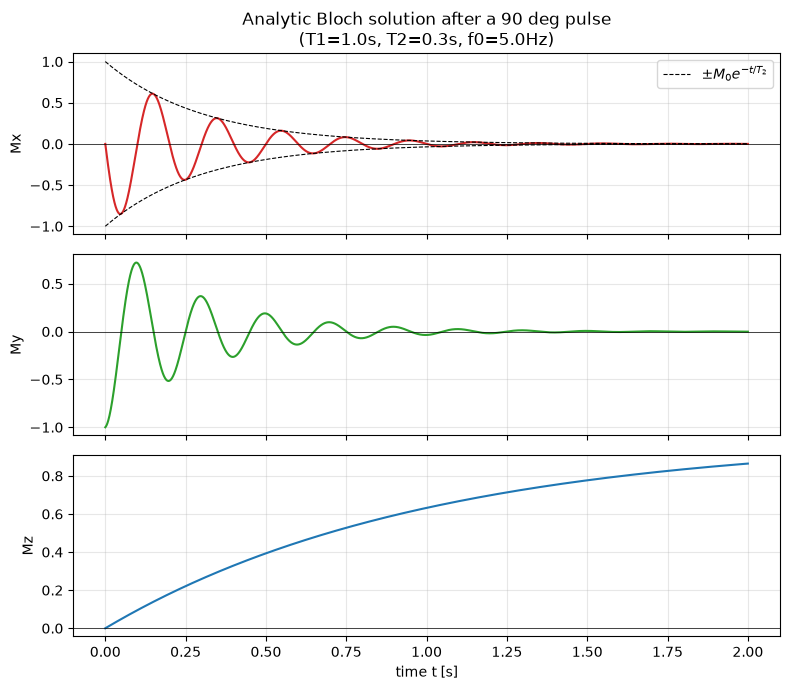

In [3]:
Mx_a = -M0 * np.exp(-t / T2) * np.sin(w0 * t)
My_a = -M0 * np.exp(-t / T2) * np.cos(w0 * t)
Mz_a =  M0 * (1 - np.exp(-t / T1))

fig, ax = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
ax[0].plot(t, Mx_a, color="tab:red");   ax[0].set_ylabel("Mx")
ax[1].plot(t, My_a, color="tab:green"); ax[1].set_ylabel("My")
ax[2].plot(t, Mz_a, color="tab:blue");  ax[2].set_ylabel("Mz")
ax[2].set_xlabel("time t [s]")
for a_ in ax:
    a_.axhline(0, color="k", lw=0.5)
    a_.grid(alpha=0.3)
ax[0].set_title(f"Analytic Bloch solution after a {alpha:.0f} deg pulse\n"
                f"(T1={T1}s, T2={T2}s, f0={f0}Hz)")
# T2 decay envelope on the transverse components
ax[0].plot(t,  M0 * np.exp(-t / T2), "k--", lw=0.8, label=r"$\pm M_0 e^{-t/T_2}$")
ax[0].plot(t, -M0 * np.exp(-t / T2), "k--", lw=0.8)
ax[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

## Numerical solution (verify with `solve_ivp`)
We integrate the coupled Bloch ODEs directly and confirm the numerical result matches the analytic
one.

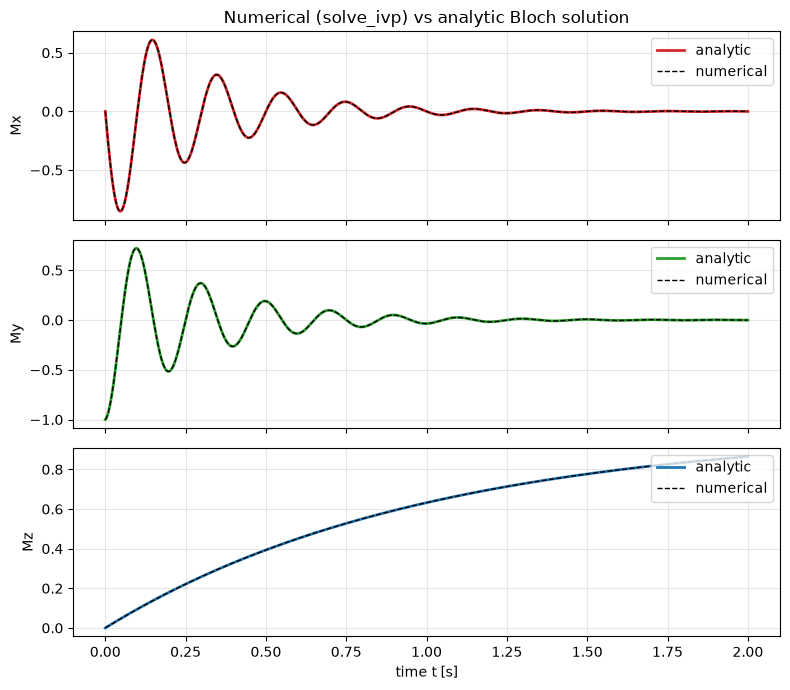

max |numerical - analytic|: 5.641421219060305e-10


In [4]:
def bloch(t, M, w0, T1, T2, M0):
    Mx, My, Mz = M
    dMx = w0 * My - Mx / T2
    dMy = -w0 * Mx - My / T2
    dMz = -(Mz - M0) / T1
    return [dMx, dMy, dMz]


sol = solve_ivp(bloch, (0, t_end), M_init, t_eval=t,
                args=(w0, T1, T2, M0), rtol=1e-9, atol=1e-12)
Mx_n, My_n, Mz_n = sol.y

fig, ax = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
for a_, num, ana, lab, c in zip(
        ax, (Mx_n, My_n, Mz_n), (Mx_a, My_a, Mz_a),
        ("Mx", "My", "Mz"), ("tab:red", "tab:green", "tab:blue")):
    a_.plot(t, ana, c, lw=2, label="analytic")
    a_.plot(t, num, "k--", lw=1, label="numerical")
    a_.set_ylabel(lab); a_.grid(alpha=0.3); a_.legend(loc="upper right")
ax[2].set_xlabel("time t [s]")
ax[0].set_title("Numerical (solve_ivp) vs analytic Bloch solution")
plt.tight_layout()
plt.show()

print("max |numerical - analytic|:",
      float(np.max(np.abs(np.array([Mx_n, My_n, Mz_n]) - np.array([Mx_a, My_a, Mz_a])))))

## 3D trajectory of the magnetization vector
The tip of $\mathbf{M}(t)$ spirals: the transverse projection shrinks (T2) while it precesses, and
the vector rises back toward $M_0\hat z$ (T1).

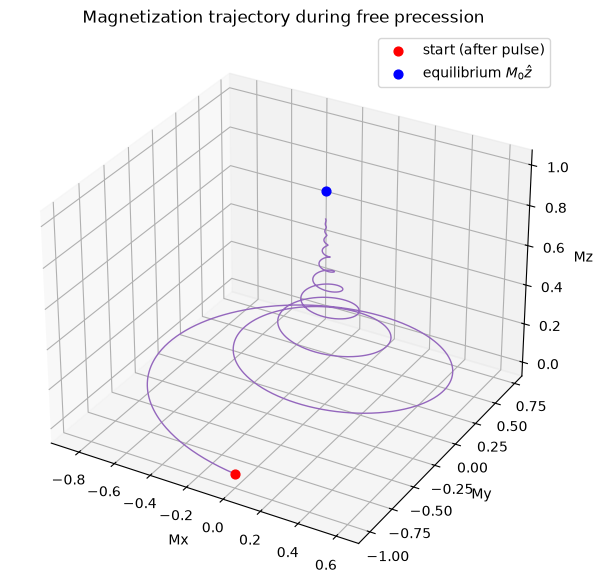

In [5]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(Mx_a, My_a, Mz_a, color="tab:purple", lw=1)
ax.scatter(*M_init, color="red", s=40, label="start (after pulse)")
ax.scatter(0, 0, M0, color="blue", s=40, label="equilibrium $M_0\\hat z$")
ax.set_xlabel("Mx"); ax.set_ylabel("My"); ax.set_zlabel("Mz")
ax.set_title("Magnetization trajectory during free precession")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways
- After a 90° pulse, $\mathbf{M}$ lies in the transverse plane and **precesses at $\omega_0=\gamma B_0$**.
- $M_x, M_y$ oscillate and decay with the **$T_2$** envelope $e^{-t/T_2}$ (loss of transverse coherence).
- $M_z$ recovers toward $M_0$ with **$T_1$** as $M_0(1-e^{-t/T_1})$.
- The numerical integration matches the analytic solution, validating the approximations.

## Tumor vs normal tissue: comparing precession spirals

Using measured relaxation times, we compare a **normal tissue** and a **tumor** whose $T_1, T_2$ differ:

| Tissue | $T_1$ [s] | $T_2$ [s] |
|---|---|---|
| normal liver | 0.293 | 0.050 |
| Novikoff hepatoma (tumor) | 0.826 | 0.118 |

The tumor's **longer $T_2$** keeps the transverse magnetization coherent for more precession turns
(a wider, longer-lived spiral), while its **longer $T_1$** makes $M_z$ climb back toward $M_0$ more
slowly. Overlaying the two 3D spirals makes this contrast visible.

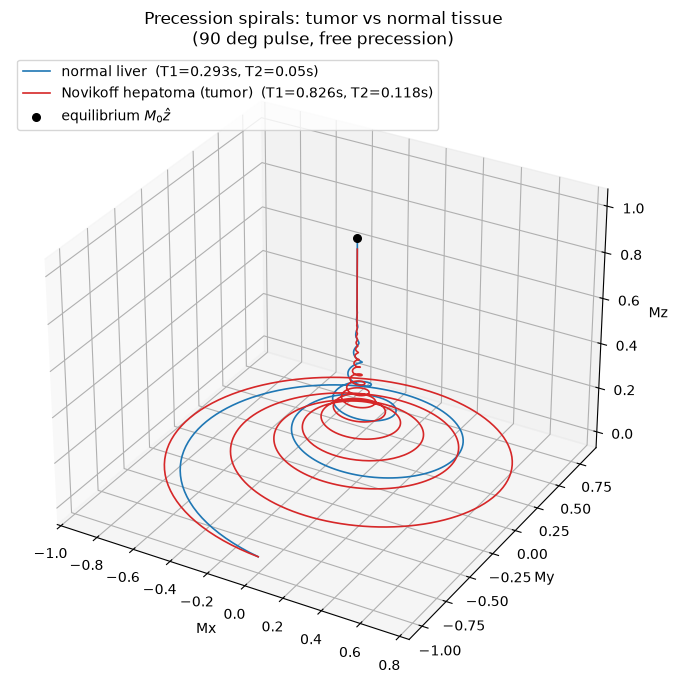

In [6]:
# Relaxation times (seconds) from the tissue relaxometry tables
TISSUES = {
    "normal liver":              {"T1": 0.293, "T2": 0.050, "color": "tab:blue"},
    "Novikoff hepatoma (tumor)": {"T1": 0.826, "T2": 0.118, "color": "tab:red"},
}

f_viz = 20.0                       # demonstration precession frequency [Hz]
w_viz = 2 * np.pi * f_viz
t_viz = np.linspace(0, 2.5, 6000)


def spiral(T1, T2, w=w_viz, t=t_viz, M0=M0):
    """Analytic free-precession magnetization after a 90 deg pulse."""
    Mx = -M0 * np.exp(-t / T2) * np.sin(w * t)
    My = -M0 * np.exp(-t / T2) * np.cos(w * t)
    Mz = M0 * (1 - np.exp(-t / T1))
    return Mx, My, Mz


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
for name, p in TISSUES.items():
    Mx, My, Mz = spiral(p["T1"], p["T2"])
    ax.plot(Mx, My, Mz, color=p["color"], lw=1.2,
            label=f"{name}  (T1={p['T1']}s, T2={p['T2']}s)")

ax.scatter(0, 0, M0, color="k", s=30, label=r"equilibrium $M_0\hat z$")
ax.set_xlabel("Mx"); ax.set_ylabel("My"); ax.set_zlabel("Mz")
ax.set_title("Precession spirals: tumor vs normal tissue\n(90 deg pulse, free precession)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()